# Used Cars — Craigslist
### Limpieza, análisis exploratorio y preparación de datos

---
Dataset: [Craigslist Cars and Trucks — Kaggle](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data)


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 25)

---
## 1. Carga del dataset

### Origen
Dataset scrapeado de **Craigslist**, el sitio de clasificados más grande de Estados Unidos. Publicado en Kaggle por *austinreese*.

### Problema que aborda
Predecir el **precio de un automóvil usado** a partir de características como fabricante, modelo, año, kilometraje, condición y tipo de combustible.

### Justificación de la elección
- Contiene suciedad real: precios imposibles, nulos en columnas clave, valores inconsistentes en categóricas.
- Mezcla de variables numéricas y categóricas que requieren transformaciones concretas.
- Gran volumen de datos (426k filas) que representa un caso realista de preprocesamiento.


In [2]:


datos = pd.read_csv(r"C:\Users\joel_\Downloads\used_cars_dataset\data\dataset.csv", encoding="latin-1")

print(f"Shape: {datos.shape}")

pd.set_option("display.max_columns", 25)

Shape: (426880, 26)


---
## 2. Análisis Exploratorio Inicial (EDA)


### 2.1 Vista general

In [3]:
datos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [4]:
datos.describe()


,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [5]:
datos.describe(include="object")


,url,region,region_url,manufacturer,model,condition,cylinders,fuel,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,state,posting_date
count,426880,426880,426880,409234,421603,252776,249202,423867,418638,424324,265838,296313,120519,334022,296677,426812,426810,426880,426812
unique,426880,404,413,42,29667,6,8,5,6,3,118264,3,4,13,12,241899,360911,51,381536
top,https://wyoming.craigslist.org/ctd/d/atlanta-2...,columbus,https://spokane.craigslist.org,ford,f-150,good,6 cylinders,gas,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,https://images.craigslist.org/00N0N_1xMPvfxRAI...,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,ca,2021-04-23T22:13:05-0400
freq,1,3608,2988,70985,8009,121456,94169,356209,405117,336524,261,131904,63465,87056,79285,7357,231,50614,12


### 2.2 Valores nulos

In [6]:
cantidad_nulos = datos.isnull().sum()
porcentaje_nulos = (cantidad_nulos / len(datos) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "nulos": cantidad_nulos,
    "porcentaje": porcentaje_nulos
}).sort_values("nulos", ascending=False)

print(resumen_nulos[resumen_nulos["nulos"] > 0])


               nulos  porcentaje
county        426880      100.00
size          306361       71.77
cylinders     177678       41.62
condition     174104       40.79
VIN           161042       37.73
drive         130567       30.59
paint_color   130203       30.50
type           92858       21.75
manufacturer   17646        4.13
title_status    8242        1.93
lat             6549        1.53
long            6549        1.53
model           5277        1.24
odometer        4400        1.03
fuel            3013        0.71
transmission    2556        0.60
year            1205        0.28
description       70        0.02
posting_date      68        0.02
image_url         68        0.02


De acá ya podemos sacar algunas conclusiones:
- `county` tiene el 100% de nulos, se elimina directamente.
- `size`, `cylinders`, `condition`, `drive` y `paint_color` tienen entre 30% y 70% de nulos, hay que decidir si imputar o eliminar.
- `VIN`, `url`, `region_url`, `image_url`, `description` no aportan información útil para el modelo.


### 2.3 Análisis del target (price)

In [8]:
print("Estadisticas del precio:")
print(datos["price"].describe())
print()
print(f"Precios = 0:         {(datos['price'] == 0).sum()}")
print(f"Precios > 100.000:   {(datos['price'] > 100000).sum()}")
print(f"Precios > 1.000.000: {(datos['price'] > 1000000).sum()}")


Estadisticas del precio:
count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

Precios = 0:         32895
Precios > 100.000:   655
Precios > 1.000.000: 53


### 2.4 Distribución de variables numéricas

In [9]:
print("Año:")
print(datos["year"].describe())
print()
print("Odometro:")
print(datos["odometer"].describe())


Año:
count    425675.000000
mean       2011.235191
std           9.452120
min        1900.000000
25%        2008.000000
50%        2013.000000
75%        2017.000000
max        2022.000000
Name: year, dtype: float64

Odometro:
count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64


### 2.5 Distribución de variables categóricas

In [10]:
columnas_categoricas = ["manufacturer", "condition", "fuel", "transmission", "type", "title_status", "drive"]

for columna in columnas_categoricas:
    print(f"\n{columna}:")
    print(datos[columna].value_counts().head(10))



manufacturer:
manufacturer
ford         70985
chevrolet    55064
toyota       34202
honda        21269
nissan       19067
jeep         19014
ram          18342
gmc          16785
bmw          14699
dodge        13707
Name: count, dtype: int64

condition:
condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

fuel:
fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64

transmission:
transmission
automatic    336524
other         62682
manual        25118
Name: count, dtype: int64

type:
type
sedan          87056
SUV            77284
pickup         43510
truck          35279
other          22110
coupe          19204
hatchback      16598
wagon          10751
van             8548
convertible     7731
Name: count, dtype: int64

title_status:
title_status
clean         405117
rebuilt         7219
salvage         3868
li

---
## 3. Limpieza de datos


### 3.1 Eliminación de columnas irrelevantes

In [11]:
# Columnas que no aportan información útil para predecir precio
columnas_a_eliminar = [
    "id",           # identificador interno
    "url",          # url del anuncio
    "region_url",   # url de la region
    "image_url",    # url de la imagen
    "description",  # texto libre sin estructura
    "VIN",          # numero de chasis, no predictivo
    "county",       # 100% nulos
    "lat",          # coordenadas geograficas, no relevantes para precio
    "long",
    "posting_date", # fecha del anuncio, no del auto
    "region",       # demasiados valores unicos (404), state lo resume mejor
]

datos.drop(columns=columnas_a_eliminar, inplace=True)
print(f"Shape despues de eliminar columnas: {datos.shape}")
print(f"Columnas restantes: {datos.columns.tolist()}")


Shape despues de eliminar columnas: (426880, 15)
Columnas restantes: ['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']


### 3.2 Corrección de tipos de datos

In [12]:
print("Tipos de datos actuales:")
print(datos.dtypes)


Tipos de datos actuales:
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
drive            object
size             object
type             object
paint_color      object
state            object
dtype: object


In [13]:
# year debe ser entero, viene como float por los nulos
datos["year"] = pd.to_numeric(datos["year"], errors="coerce")

# odometer debe ser entero
datos["odometer"] = pd.to_numeric(datos["odometer"], errors="coerce")

print("Tipos corregidos:")
print(datos[["year", "odometer", "price"]].dtypes)


Tipos corregidos:
year        float64
odometer    float64
price         int64
dtype: object


##Acotacion :

Digo que voy a convertir los tipos de datos a INT usando pd.to_numeric, pero sigue diciendo float porque pd.to_numeric solo convierte los valores a numérico sin forzar el tipo a entero. Como todavía pueden existir nulos en esas columnas, pandas los mantiene como float64 — un entero no puede representar NaN. El .astype(int) se aplica más adelante, una vez finalizada la imputación de nulos.


### 3.3 Outliers en precio, año y odómetro

In [14]:
filas_antes = datos.shape[0]

# Filtrar precios fuera de rango razonable para autos usados
datos = datos[(datos["price"] >= 500) & (datos["price"] <= 100000)]

# Filtrar años imposibles
datos = datos[(datos["year"] >= 1980) & (datos["year"] <= 2023)]

# Filtrar odometro imposible
datos = datos[datos["odometer"] <= 500000]

filas_despues = datos.shape[0]
eliminadas = filas_antes - filas_despues

print(f"Filas antes:   {filas_antes}")
print(f"Filas despues: {filas_despues}")
print(f"Eliminadas:    {eliminadas} ({eliminadas / filas_antes * 100:.1f}%)")


Filas antes:   426880
Filas despues: 372094
Eliminadas:    54786 (12.8%)


### 3.4 Inconsistencias en variables categóricas

In [15]:
# Normalizar: minusculas y sin espacios extra
cols_texto = datos.select_dtypes(include="object").columns.tolist()

for columna in cols_texto:
    datos[columna] = datos[columna].astype(str).str.strip().str.lower()
    datos[columna] = datos[columna].replace(["nan", "other", "unknown", ""], np.nan)

print("Normalizacion completada")
print()
print("Nulos despues de normalizacion:")
print(datos[cols_texto].isnull().sum().sort_values(ascending=False))


Normalizacion completada

Nulos despues de normalizacion:
size            268091
cylinders       153635
condition       140801
drive           112715
paint_color     107001
type             97870
transmission     61936
fuel             29278
manufacturer     12244
title_status      6487
model             3638
state                0
dtype: int64


### 3.5 Tratamiento de valores nulos

In [16]:
# Columnas con muchos nulos
cols_con_nulos = ["size", "cylinders", "condition", "drive", "paint_color"]

print("Porcentaje de nulos en columnas problematicas:")
for columna in cols_con_nulos:
    porcentaje = datos[columna].isnull().sum() / len(datos) * 100
    print(f"  {columna}: {porcentaje:.1f}%")


Porcentaje de nulos en columnas problematicas:
  size: 72.0%
  cylinders: 41.3%
  condition: 37.8%
  drive: 30.3%
  paint_color: 28.8%


In [17]:
# Columnas con mas del 40% de nulos se eliminan, el resto se imputa con la moda
umbral = 40

cols_eliminar = []
cols_imputar = []

for columna in cols_con_nulos:
    porcentaje = datos[columna].isnull().sum() / len(datos) * 100
    if porcentaje > umbral:
        cols_eliminar.append(columna)
    else:
        cols_imputar.append(columna)

print(f"Columnas a eliminar (> {umbral}% nulos): {cols_eliminar}")
print(f"Columnas a imputar: {cols_imputar}")

datos.drop(columns=cols_eliminar, inplace=True)

for columna in cols_imputar:
    moda = datos[columna].mode()[0]
    datos[columna].fillna(moda, inplace=True)
    print(f"  {columna}: imputado con '{moda}'")


Columnas a eliminar (> 40% nulos): ['size', 'cylinders']
Columnas a imputar: ['condition', 'drive', 'paint_color']
  condition: imputado con 'good'
  drive: imputado con '4wd'
  paint_color: imputado con 'white'


C:\Users\joel_\AppData\Local\Temp\ipykernel_29648\1568690231.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datos[columna].fillna(moda, inplace=True)


In [18]:
# Imputar nulos restantes
for columna in datos.columns:
    cantidad = datos[columna].isnull().sum()
    if cantidad == 0:
        continue
    if datos[columna].dtype == "object":
        moda = datos[columna].mode()[0]
        datos[columna].fillna(moda, inplace=True)
        print(f"  {columna}: imputado con moda = '{moda}'")
    else:
        mediana = datos[columna].median()
        datos[columna].fillna(mediana, inplace=True)
        print(f"  {columna}: imputado con mediana = {mediana}")

print(f"\nNulos restantes: {datos.isnull().sum().sum()}")


C:\Users\joel_\AppData\Local\Temp\ipykernel_29648\1860265851.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datos[columna].fillna(moda, inplace=True)


  manufacturer: imputado con moda = 'ford'
  model: imputado con moda = 'f-150'
  fuel: imputado con moda = 'gas'
  title_status: imputado con moda = 'clean'
  transmission: imputado con moda = 'automatic'
  type: imputado con moda = 'sedan'

Nulos restantes: 0


In [19]:
# una vez que no hay mas nulos, convierto a entero
datos["year"] = datos["year"].astype(int)
datos["odometer"] = datos["odometer"].astype(int)

print(datos[["year", "odometer", "price"]].dtypes)

year        int64
odometer    int64
price       int64
dtype: object


### 3.6 Duplicados

In [20]:
duplicados = datos.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")

datos.drop_duplicates(inplace=True)
print(f"Shape final: {datos.shape}")


Duplicados encontrados: 109768
Shape final: (262326, 13)


---
## 4. Selección de variables y transformaciones


### 4.1 Selección de variables

In [21]:
print("Columnas disponibles:")
print(datos.columns.tolist())


Columnas disponibles:
['price', 'year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']


In [22]:
variables_numericas = ["year", "odometer"]
variables_categoricas = ["manufacturer", "fuel", "transmission", "type", "title_status", "state"]
variable_objetivo = "price"

# Justificacion:
# year: la antiguedad del auto tiene impacto directo en el precio
# odometer: a mayor kilometraje, menor precio
# manufacturer: la marca influye mucho en el valor de mercado
# fuel: el tipo de combustible afecta la demanda y precio
# transmission: automatico vs manual tiene diferencia de precio
# type: sedan, SUV, pickup tienen rangos de precio muy distintos
# title_status: si el titulo esta limpio o tiene salvage baja mucho el precio
# state: el mercado varia segun el estado de EE.UU.

# Variables descartadas:
# model: demasiados valores unicos (29k+), necesitaria procesamiento especial
# condition/drive: eliminadas por alto porcentaje de nulos

variables = variables_numericas + variables_categoricas
print(f"Variables seleccionadas: {variables}")
print(f"Variable objetivo: {variable_objetivo}")

datos_modelo = datos[variables + [variable_objetivo]].copy()
print(f"\nShape del dataset para modelado: {datos_modelo.shape}")


Variables seleccionadas: ['year', 'odometer', 'manufacturer', 'fuel', 'transmission', 'type', 'title_status', 'state']
Variable objetivo: price

Shape del dataset para modelado: (262326, 9)


### 4.2 Codificación de variables categóricas

In [23]:
codificador = LabelEncoder()

for columna in variables_categoricas:
    datos_modelo[columna] = codificador.fit_transform(datos_modelo[columna].astype(str))
    print(f"  {columna}: {datos[columna].nunique()} categorias codificadas")

print("\nEncoding completado.")


  manufacturer: 42 categorias codificadas
  fuel: 4 categorias codificadas
  transmission: 2 categorias codificadas
  type: 12 categorias codificadas
  title_status: 6 categorias codificadas
  state: 51 categorias codificadas

Encoding completado.


### 4.3 Escalado de variables numéricas

In [24]:
escalador = StandardScaler()
datos_modelo[variables_numericas] = escalador.fit_transform(datos_modelo[variables_numericas])

print("Variables escaladas:", variables_numericas)
print()
datos_modelo[variables_numericas].describe().round(3)


Variables escaladas: ['year', 'odometer']



,year,odometer
count,262326.000,262326.000
mean,-0.000,-0.000
std,1.000,1.000
min,-4.621,-1.505
25%,-0.637,-0.849
50%,0.248,-0.068
75%,0.838,0.659
max,1.576,6.126


### 4.4 Visualización de variables seleccionadas

Correlacion con precio:
year            0.545
odometer        0.528
fuel            0.267
title_status    0.087
transmission    0.077
manufacturer    0.052
state           0.012
type            0.008
Name: price, dtype: float64


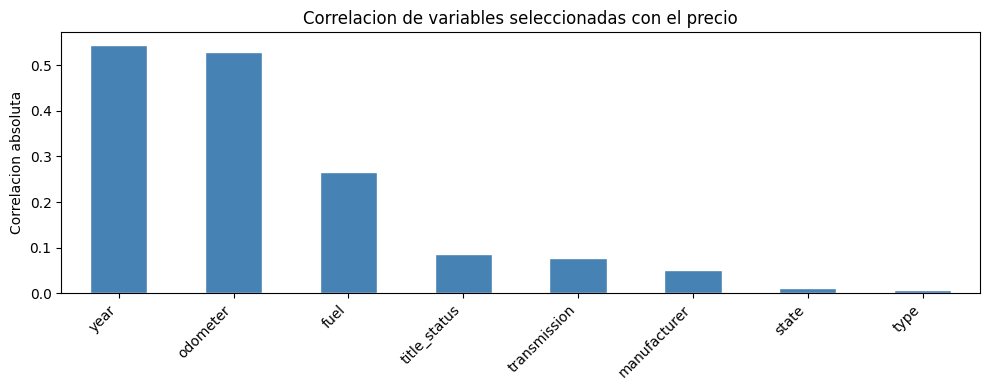

In [25]:
correlacion_con_precio = datos_modelo.corr()["price"].drop("price").abs().sort_values(ascending=False)

print("Correlacion con precio:")
print(correlacion_con_precio.round(3))

correlacion_con_precio.plot(kind="bar", figsize=(10, 4), color="steelblue", edgecolor="white")
plt.title("Correlacion de variables seleccionadas con el precio")
plt.ylabel("Correlacion absoluta")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


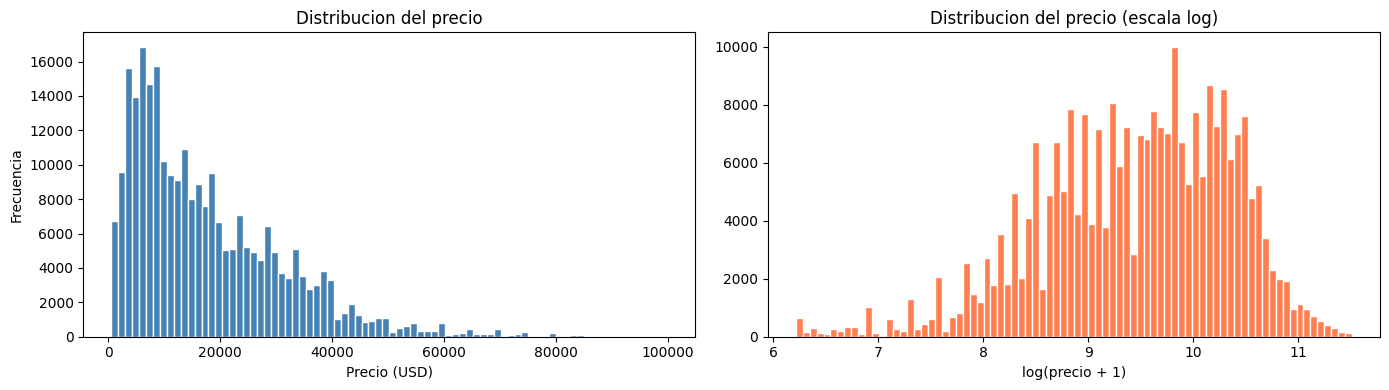

In [26]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4))

ejes[0].hist(datos_modelo["price"], bins=80, color="steelblue", edgecolor="white")
ejes[0].set_title("Distribucion del precio")
ejes[0].set_xlabel("Precio (USD)")
ejes[0].set_ylabel("Frecuencia")

ejes[1].hist(np.log1p(datos_modelo["price"]), bins=80, color="coral", edgecolor="white")
ejes[1].set_title("Distribucion del precio (escala log)")
ejes[1].set_xlabel("log(precio + 1)")

plt.tight_layout()
plt.show()


---
## 5. División del dataset


In [27]:
X = datos_modelo[variables]
y = datos_modelo[variable_objetivo]

X_entreno, X_prueba, y_entreno, y_prueba = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Division del dataset:")
print(f"  Total:         {len(X)}")
print(f"  Entrenamiento: {len(X_entreno)} ({len(X_entreno)/len(X)*100:.0f}%)")
print(f"  Prueba:        {len(X_prueba)} ({len(X_prueba)/len(X)*100:.0f}%)")
print()
print(f"Media precio entreno: {y_entreno.mean():.2f}")
print(f"Media precio prueba:  {y_prueba.mean():.2f}")


Division del dataset:
  Total:         262326
  Entrenamiento: 209860 (80%)
  Prueba:        52466 (20%)

Media precio entreno: 17767.01
Media precio prueba:  17845.46



## Resumen del proceso

| Etapa | Acciones realizadas |
|---|---|
|Carga | CSV desde Google Drive.|
|EDA | Vista general, nulos, estadisticas del target, distribución de categóricas |
|Limpieza| Eliminacion de columnas irrelevantes, correccion de tipos, filtro de outliers en precio/año/odometro, normalizacion de categoricas, imputacion de nulos, deduplicacion |
|Selección de variables| 8 variables seleccionadas con justificacion, descarte de columnas con demasiados valores unicos o nulos |
|Encoding | Label Encoding para 6 variables categoricas |
|Escalado| StandardScaler para year y odometer |
|Visualizacion| Correlacion de variables con el precio, distribucion del precio |
|Split| 80% entrenamiento / 20% prueba con random_state=42 |
